# ****SetUp****

In [13]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {torch.cuda.get_device_name(0)}")

HAM_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
os.makedirs("/kaggle/working/gan_checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/generated_images", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

# Load metadata
meta = pd.read_csv(f"{HAM_PATH}/HAM10000_metadata.csv")
print(f"✓ Metadata loaded: {meta.shape}")
print(f"\nClass distribution:")
print(meta['dx'].value_counts())

# Image dirs
img_dir1 = f"{HAM_PATH}/HAM10000_images_part_1"
img_dir2 = f"{HAM_PATH}/HAM10000_images_part_2"

def find_image_path(image_id):
    for d in [img_dir1, img_dir2]:
        path = os.path.join(d, f"{image_id}.jpg")
        if os.path.exists(path):
            return path
    return None

meta['image_path'] = meta['image_id'].apply(find_image_path)
meta = meta.dropna(subset=['image_path']).reset_index(drop=True)

le = LabelEncoder()
meta['label'] = le.fit_transform(meta['dx'])
NUM_CLASSES = len(le.classes_)

print(f"\n✓ Image paths built")
print(f"  Total images : {len(meta)}")
print(f"  Classes      : {NUM_CLASSES}")
print(f"  Labels       : {list(le.classes_)}")

✓ Device: Tesla T4
✓ Metadata loaded: (10015, 7)

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

✓ Image paths built
  Total images : 10015
  Classes      : 7
  Labels       : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


# ****FastGAN Architecture (128×128)****

In [15]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(x + self.conv(x))


class FastGANGenerator(nn.Module):
    def __init__(self, nz=128, ngf=64):
        super().__init__()
        self.nz = nz
        self.init = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*16),
            nn.ReLU(True)
        )
        self.upsample = nn.Sequential(
            # 4 → 8
            nn.ConvTranspose2d(ngf*16, ngf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            ResBlock(ngf*8),
            # 8 → 16
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            ResBlock(ngf*4),
            # 16 → 32
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            ResBlock(ngf*2),
            # 32 → 64
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            ResBlock(ngf),
            # 64 → 128
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, self.nz, 1, 1)
        return self.upsample(self.init(z))


class FastGANDiscriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        def block(ic, oc, s=2):
            return nn.Sequential(
                nn.utils.spectral_norm(
                    nn.Conv2d(ic, oc, 4, s, 1, bias=False)),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.net = nn.Sequential(
            block(3,      ndf),
            block(ndf,    ndf*2),
            block(ndf*2,  ndf*4),
            block(ndf*4,  ndf*8),
            block(ndf*8,  ndf*16),
            nn.Conv2d(ndf*16, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)


NZ  = 128
IMG = 128

G = FastGANGenerator(nz=NZ, ngf=64).to(device)
D = FastGANDiscriminator(ndf=64).to(device)

g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())

print(f"✓ FastGAN (128×128) built")
print(f"  Generator params     : {g_params:,}")
print(f"  Discriminator params : {d_params:,}")

# Test
z    = torch.randn(4, NZ).to(device)
imgs = G(z)
print(f"  Output shape         : {imgs.shape}")

✓ FastGAN (128×128) built
  Generator params     : 19,516,032
  Discriminator params : 11,160,577
  Output shape         : torch.Size([4, 3, 128, 128])


In [30]:
gan_models = {}

checkpoint_dir = "/kaggle/working/gan_checkpoints"

for file in os.listdir(checkpoint_dir):
    if file.endswith(".pt"):
        disease = file.replace("G_", "").replace(".pt", "")
        
        print(f"Loading model for: {disease}")
        
        G_cls = FastGANGenerator(nz=NZ, ngf=64).to(device)
        G_cls.load_state_dict(torch.load(os.path.join(checkpoint_dir, file)))
        G_cls.eval()
        
        gan_models[disease] = G_cls

print(f"\n✓ Loaded {len(gan_models)} GAN models successfully")

Loading model for: akiec
Loading model for: bcc
Loading model for: vasc
Loading model for: df
Loading model for: bkl
Loading model for: mel

✓ Loaded 6 GAN models successfully


# ****GAN Dataset + Training Function****

In [9]:
class HAMClassDataset(Dataset):
    def __init__(self, df, disease_label, img_size=128):
        self.samples   = []
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2,
                saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])
        class_df = df[df['label'] == disease_label]
        self.samples = class_df['image_path'].tolist()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        try:
            img = Image.open(
                self.samples[idx]).convert('RGB')
            return self.transform(img)
        except:
            return torch.zeros(3, 128, 128)


def train_gan(G, D, dataloader, device,
              epochs=1000, nz=128, lr=2e-4):
    opt_G = Adam(G.parameters(),
                 lr=lr, betas=(0.5, 0.999))
    opt_D = Adam(D.parameters(),
                 lr=lr, betas=(0.5, 0.999))

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        g_ep, d_ep, n = 0, 0, 0

        for real_imgs in dataloader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # Train D
            opt_D.zero_grad()
            d_real  = D(real_imgs)
            l_real  = F.relu(1.0 - d_real).mean()
            z       = torch.randn(bs, nz).to(device)
            l_fake  = F.relu(1.0 + D(G(z).detach())).mean()
            d_loss  = l_real + l_fake
            d_loss.backward()
            opt_D.step()

            # Train G
            opt_G.zero_grad()
            z      = torch.randn(bs, nz).to(device)
            g_loss = -D(G(z)).mean()
            g_loss.backward()
            opt_G.step()

            g_ep += g_loss.item()
            d_ep += d_loss.item()
            n    += 1

        g_losses.append(g_ep / max(n, 1))
        d_losses.append(d_ep / max(n, 1))

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:04d}/{epochs} | "
                  f"G: {g_losses[-1]:.4f} | "
                  f"D: {d_losses[-1]:.4f}")

    return g_losses, d_losses

print("✓ Training function ready")

✓ Training function ready


# ****Train GAN Per Class****

In [ ]:
# Optimized — 500 epochs, batch 32, faster per class
class_info = meta.groupby(['label', 'dx']).size().reset_index(name='count')
class_info = class_info.sort_values('count')
# Add this filter at the start of Cell 4
# Skip majority class — doesn't need augmentation
class_info = class_info[class_info['dx'] != 'nv']
print("Skipping nv (majority class — no augmentation needed)")

print("HAM10000 class sizes:")
print(class_info[['dx', 'count']].to_string(index=False))

gan_models   = {}
EPOCHS       = 500  # reduced from 1000

for _, row in class_info.iterrows():
    label   = row['label']
    disease = row['dx']
    count   = row['count']

    print(f"\nTraining GAN: {disease} ({count} samples)")

    dataset = HAMClassDataset(meta, label, img_size=IMG)
    loader  = DataLoader(dataset, batch_size=32,
                         shuffle=True, num_workers=4)

    G_cls = FastGANGenerator(nz=NZ, ngf=64).to(device)
    D_cls = FastGANDiscriminator(ndf=64).to(device)

    g_losses, d_losses = train_gan(
        G_cls, D_cls, loader, device,
        epochs=EPOCHS, nz=NZ
    )

    gan_models[disease] = G_cls

    torch.save(G_cls.state_dict(),
        f"/kaggle/working/gan_checkpoints/G_{disease}.pt")
    print(f"  ✓ Saved: G_{disease}.pt | "
          f"G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f}")

print(f"\n✓ All {len(gan_models)} GAN models trained")

# ****Generate Synthetic Images Per Class****

In [31]:
meta = pd.read_csv(f"{HAM_PATH}/HAM10000_metadata.csv")

img_dir1 = f"{HAM_PATH}/HAM10000_images_part_1"
img_dir2 = f"{HAM_PATH}/HAM10000_images_part_2"

def find_image_path(image_id):
    for d in [img_dir1, img_dir2]:
        path = os.path.join(d, f"{image_id}.jpg")
        if os.path.exists(path):
            return path
    return None

meta['image_path'] = meta['image_id'].apply(find_image_path)
meta = meta.dropna(subset=['image_path']).reset_index(drop=True)

le = LabelEncoder()
meta['label'] = le.fit_transform(meta['dx'])

In [32]:
class_info = meta.groupby(['label', 'dx']).size().reset_index(name='count')
class_info = class_info.sort_values('count')

print(class_info)

   label     dx  count
3      3     df    115
6      6   vasc    142
0      0  akiec    327
1      1    bcc    514
2      2    bkl   1099
4      4    mel   1113
5      5     nv   6705


In [33]:
def generate_images(G, n_images, nz, device):
    G.eval()
    images = []
    with torch.no_grad():
        # Generate in batches of 32
        for i in range(0, n_images, 32):
            batch = min(32, n_images - i)
            z     = torch.randn(batch, nz).to(device)
            imgs  = G(z)
            imgs  = (imgs * 0.5 + 0.5).clamp(0, 1)
            images.append(imgs.cpu())
    return torch.cat(images, dim=0)


# Generate synthetic images for each class
# Target: balance all classes to match majority class
majority_count = class_info['count'].max()
print(f"Majority class size: {majority_count}")
print(f"Generating synthetic images to balance...\n")

generated_data = {}

for disease, G_cls in gan_models.items():
    real_count = class_info[
        class_info['dx'] == disease]['count'].values[0]
    needed     = max(0, majority_count - real_count)

    if needed > 0:
        fake_imgs = generate_images(
            G_cls, needed, NZ, device)
        generated_data[disease] = {
            'images'    : fake_imgs,
            'real_count': real_count,
            'generated' : needed
        }
        print(f"  {disease:<25} : "
              f"real={real_count:4d} + "
              f"generated={needed:4d} = "
              f"{real_count+needed:4d}")
    else:
        generated_data[disease] = {
            'images'    : None,
            'real_count': real_count,
            'generated' : 0
        }
        print(f"  {disease:<25} : "
              f"real={real_count:4d} (majority — no augmentation needed)")

print(f"\n✓ Generation complete")

Majority class size: 6705
Generating synthetic images to balance...

  akiec                     : real= 327 + generated=6378 = 6705
  bcc                       : real= 514 + generated=6191 = 6705
  vasc                      : real= 142 + generated=6563 = 6705
  df                        : real= 115 + generated=6590 = 6705
  bkl                       : real=1099 + generated=5606 = 6705
  mel                       : real=1113 + generated=5592 = 6705

✓ Generation complete


# ****Visualize Generated Images****

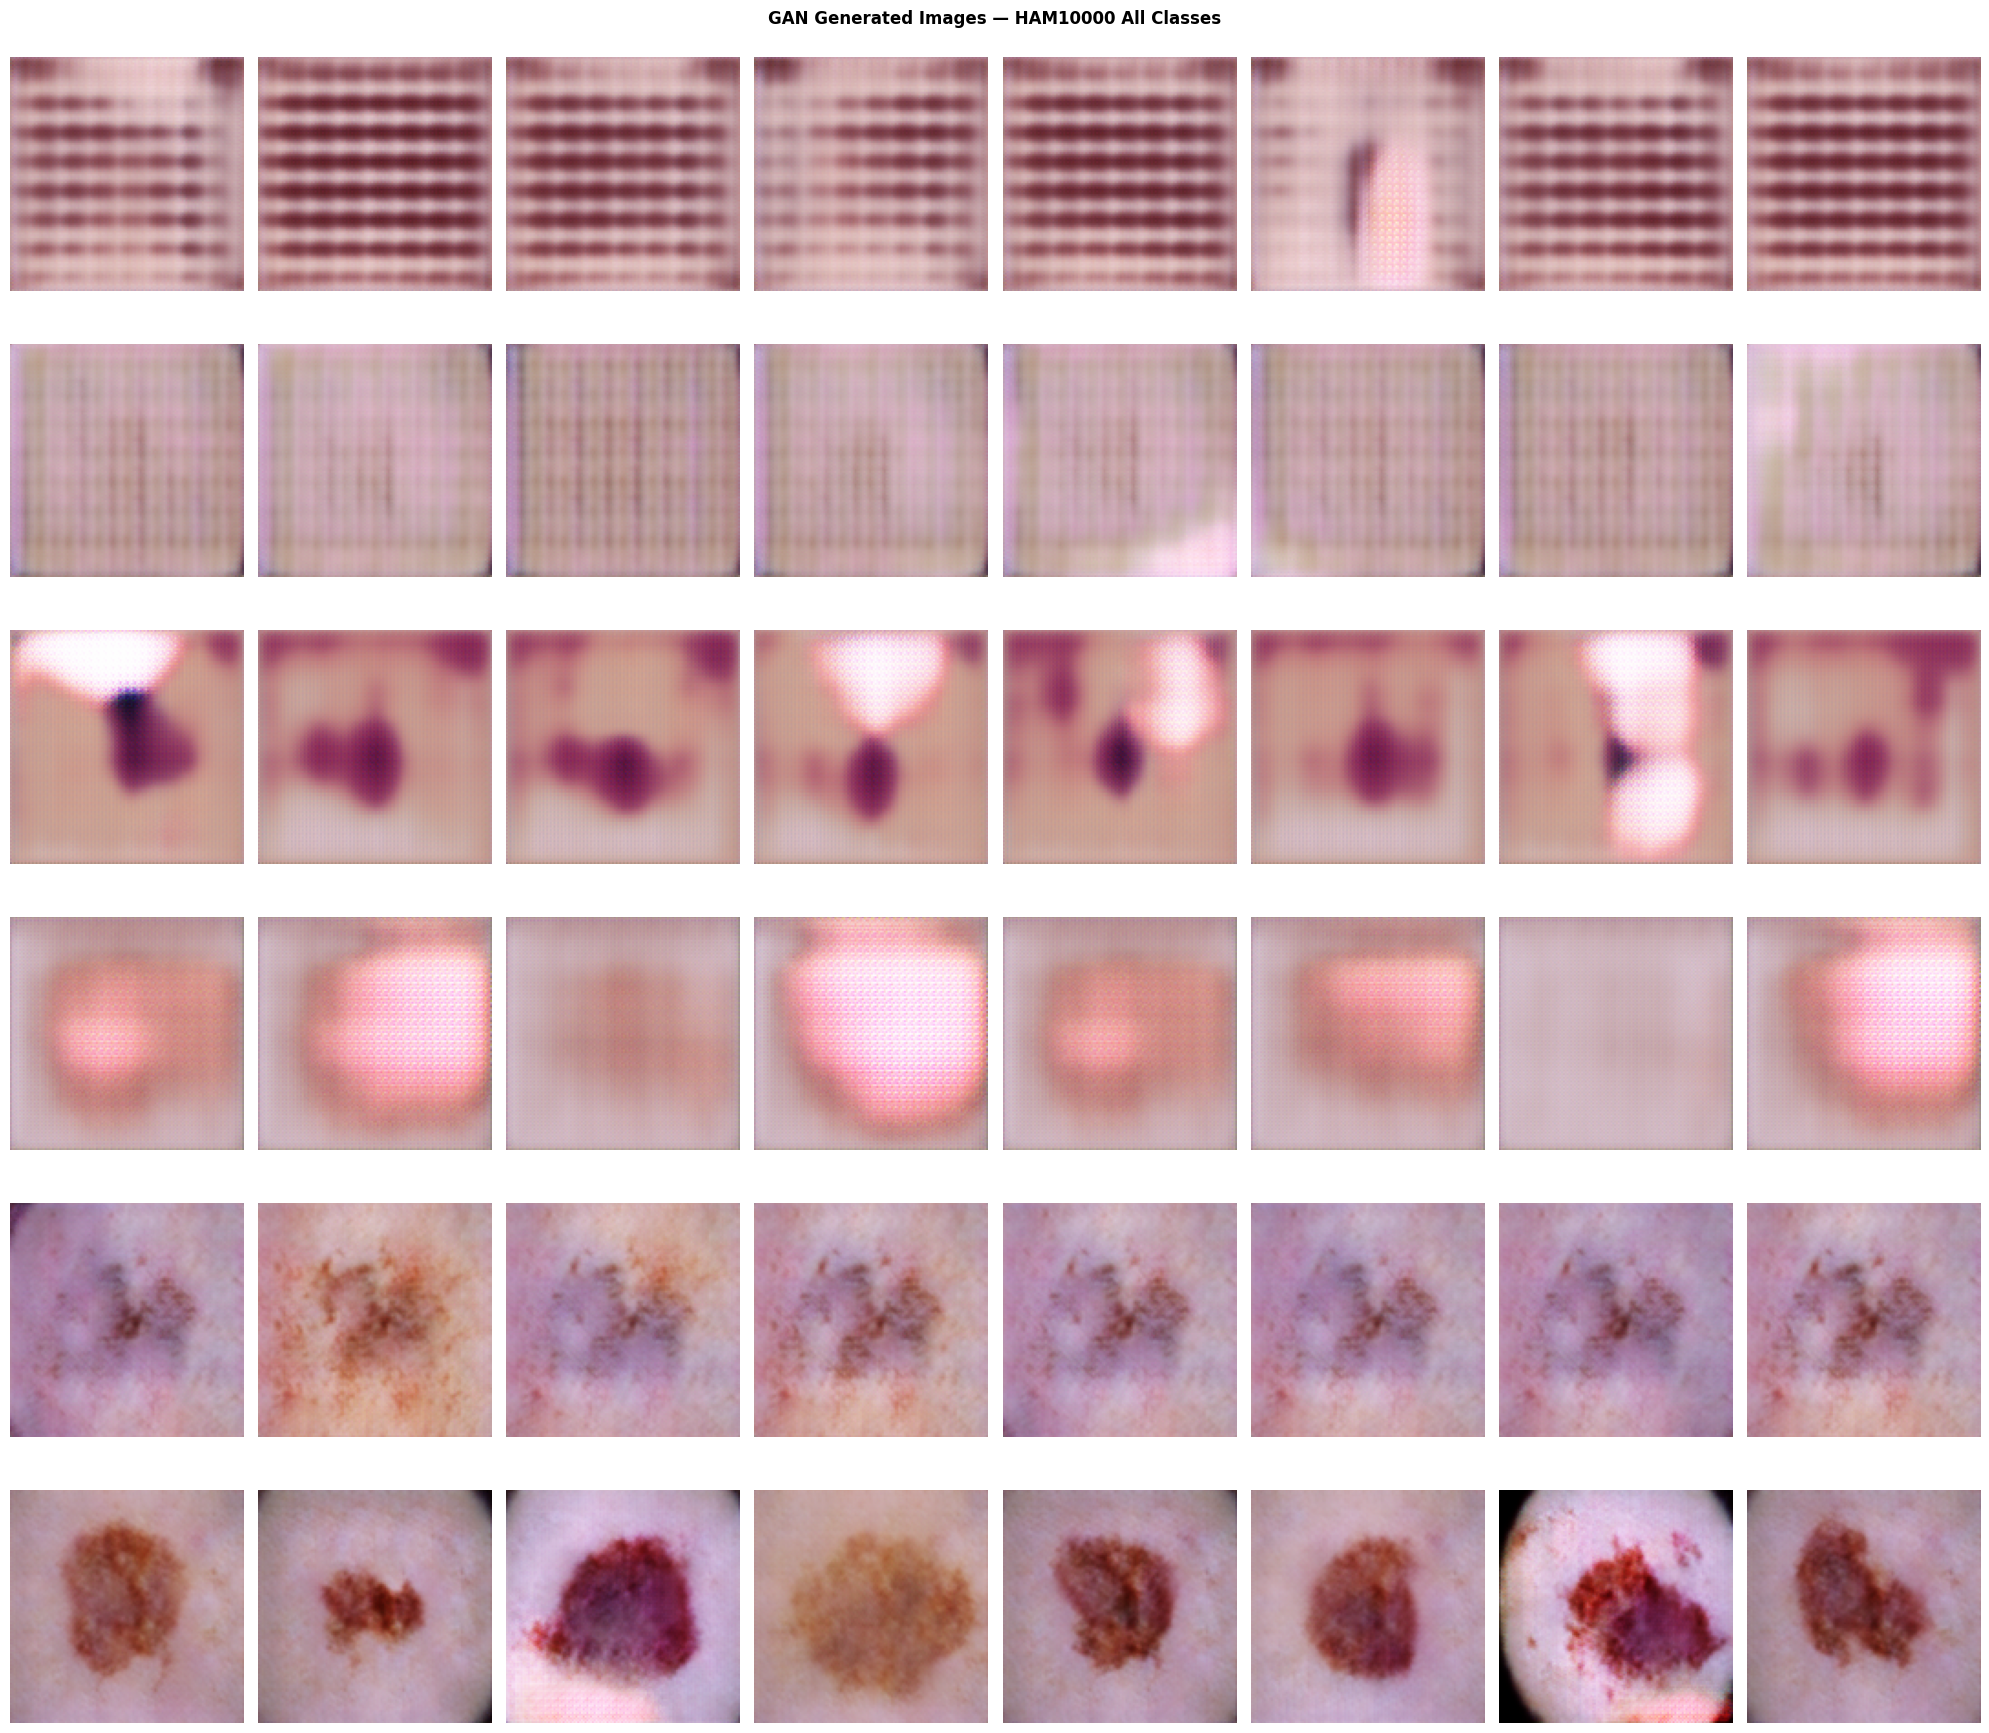

✓ All class visualization saved


In [19]:
fig, big_axes = plt.subplots(
    len(gan_models), 8, figsize=(20, 3*len(gan_models)))

for row_idx, (disease, G_cls) in enumerate(gan_models.items()):
    G_cls.eval()
    with torch.no_grad():
        z    = torch.randn(8, NZ).to(device)
        imgs = G_cls(z)
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)

    for col_idx in range(8):
        ax  = big_axes[row_idx][col_idx]
        img = imgs[col_idx].cpu().permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(disease[:15], fontsize=7,
                          rotation=0, labelpad=60,
                          va='center')

plt.suptitle('GAN Generated Images — HAM10000 All Classes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results/day10_generated_all_classes.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("✓ All class visualization saved")

# ****Save Augmented Dataset + Results****

In [20]:
import json
import os
import numpy as np

EPOCHS_PER_CLASS = 500

# Convert numpy types to Python native types
summary = {
    "day"             : 10,
    "experiment"      : "exp2_gan_augmentation_ham",
    "architecture"    : "FastGAN 128x128",
    "epochs_per_class": EPOCHS_PER_CLASS,
    "classes_trained" : len(gan_models),
    "skipped_class"   : "nv (majority)",
    "generation_results": {
        disease: {
            "real"     : int(d['real_count']),
            "generated": int(d['generated']),
            "total"    : int(d['real_count'] + d['generated'])
        }
        for disease, d in generated_data.items()
    },
    "status": "Day 10 complete"
}

os.makedirs("/kaggle/working/results", exist_ok=True)
with open("/kaggle/working/results/day10_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 55)
print("DAY 10 COMPLETE ✓")
print("=" * 55)
print(f"  GAN models trained : {len(gan_models)}")
print(f"  Epochs per class   : {EPOCHS_PER_CLASS}")
print(f"  nv class           : skipped (majority)")
print(f"\n  Generation results:")
for disease, d in generated_data.items():
    print(f"    {disease:<8}: "
          f"real={int(d['real_count']):4d} + "
          f"gen={int(d['generated']):4d} = "
          f"{int(d['real_count']+d['generated']):4d}")
print(f"\n✓ Summary saved")
print(f"  Next → Day 11: Retrain CNN with GAN data")

DAY 10 COMPLETE ✓
  GAN models trained : 6
  Epochs per class   : 500
  nv class           : skipped (majority)

  Generation results:
    akiec   : real= 327 + gen=6378 = 6705
    bcc     : real= 514 + gen=6191 = 6705
    vasc    : real= 142 + gen=6563 = 6705
    df      : real= 115 + gen=6590 = 6705
    bkl     : real=1099 + gen=5606 = 6705
    mel     : real=1113 + gen=5592 = 6705

✓ Summary saved
  Next → Day 11: Retrain CNN with GAN data


In [23]:
generated_data = {}

majority_count = class_info['count'].max()

for disease, G_cls in gan_models.items():
    real_count = class_info[
        class_info['dx'] == disease]['count'].values[0]
    needed = max(0, majority_count - real_count)

    if needed > 0:
        fake_imgs = generate_images(G_cls, needed, NZ, device)
        generated_data[disease] = fake_imgs

In [34]:
import torchvision.utils as vutils
import os

for disease, imgs in generated_data.items():
    save_dir = f"/kaggle/working/generated_images/{disease}"
    os.makedirs(save_dir, exist_ok=True)

    for i, img in enumerate(imgs):
        vutils.save_image(img, f"{save_dir}/{disease}_{i}.png")

print("✓ All generated images saved to disk")

TypeError: tensor or list of tensors expected, got <class 'str'>

In [35]:
os.listdir('/kaggle/working/generated_images/mel')

['mel_943.png',
 'mel_2100.png',
 'mel_4738.png',
 'mel_4781.png',
 'mel_3131.png',
 'mel_1097.png',
 'mel_3990.png',
 'mel_3179.png',
 'mel_2448.png',
 'mel_2773.png',
 'mel_3834.png',
 'mel_433.png',
 'mel_538.png',
 'mel_4154.png',
 'mel_5438.png',
 'mel_1066.png',
 'mel_4109.png',
 'mel_824.png',
 'mel_3259.png',
 'mel_2225.png',
 'mel_3602.png',
 'mel_1060.png',
 'mel_2462.png',
 'mel_4643.png',
 'mel_4328.png',
 'mel_1008.png',
 'mel_5578.png',
 'mel_3392.png',
 'mel_4166.png',
 'mel_117.png',
 'mel_5238.png',
 'mel_3716.png',
 'mel_4770.png',
 'mel_4577.png',
 'mel_3848.png',
 'mel_1401.png',
 'mel_99.png',
 'mel_2195.png',
 'mel_5303.png',
 'mel_1919.png',
 'mel_5092.png',
 'mel_251.png',
 'mel_3709.png',
 'mel_2842.png',
 'mel_839.png',
 'mel_4389.png',
 'mel_773.png',
 'mel_1640.png',
 'mel_3417.png',
 'mel_4621.png',
 'mel_4739.png',
 'mel_3910.png',
 'mel_3771.png',
 'mel_4847.png',
 'mel_5482.png',
 'mel_1825.png',
 'mel_666.png',
 'mel_3944.png',
 'mel_3091.png',
 'mel_61

In [29]:
generated_data = {}

majority_count = class_info['count'].max()

for disease, G_cls in gan_models.items():
    real_count = class_info[
        class_info['dx'] == disease]['count'].values[0]
    needed = max(0, majority_count - real_count)

    if needed > 0:
        fake_imgs = generate_images(G_cls, needed, NZ, device)
        generated_data[disease] = {
            'images': fake_imgs,
            'real_count': real_count,
            'generated': needed
        }
    else:
        generated_data[disease] = {
            'images': None,
            'real_count': real_count,
            'generated': 0
        }

 # Build Augmented Dataset# 
 

In [36]:
import torchvision.models as models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# ── Build augmented dataframe ──────────────────────────────────
# Start with real data
aug_rows = []

for _, row in meta.iterrows():
    aug_rows.append({
        'image_path': row['image_path'],
        'label'     : row['label'],
        'dx'        : row['dx'],
        'is_real'   : True
    })

# Add generated images
for disease, data in generated_data.items():
    if data['generated'] > 0:
        gen_dir = f"/kaggle/working/generated_images/{disease}"
        label   = meta[meta['dx'] == disease]['label'].iloc[0]
        for fname in os.listdir(gen_dir):
            aug_rows.append({
                'image_path': os.path.join(gen_dir, fname),
                'label'     : label,
                'dx'        : disease,
                'is_real'   : False
            })

aug_df = pd.DataFrame(aug_rows)

print(f"✓ Augmented dataset built")
print(f"  Real images      : {aug_df['is_real'].sum()}")
print(f"  Synthetic images : {(~aug_df['is_real']).sum()}")
print(f"  Total            : {len(aug_df)}")
print(f"\nClass distribution after augmentation:")
print(aug_df['dx'].value_counts())

✓ Augmented dataset built
  Real images      : 10015
  Synthetic images : 40288
  Total            : 50303

Class distribution after augmentation:
dx
df       7703
vasc     7676
akiec    7491
bcc      7304
bkl      6719
nv       6705
mel      6705
Name: count, dtype: int64


# ****Dataset + DataLoader****# 

In [37]:
class HAMAugDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except:
            img = torch.zeros(3, 224, 224)
        return {
            'image': img,
            'label': torch.tensor(int(row['label']),
                                  dtype=torch.long)
        }

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Split augmented data 80/20
# Use only REAL images for test set
real_df = aug_df[aug_df['is_real']].reset_index(drop=True)
synt_df = aug_df[~aug_df['is_real']].reset_index(drop=True)

real_train, real_test = train_test_split(
    real_df, test_size=0.2,
    random_state=42, stratify=real_df['dx']
)

# Train = real_train + all synthetic
train_df_aug = pd.concat(
    [real_train, synt_df]).reset_index(drop=True)
test_df_aug  = real_test.reset_index(drop=True)

train_ds = HAMAugDataset(train_df_aug, train_transform)
test_ds  = HAMAugDataset(test_df_aug,  test_transform)

train_loader = DataLoader(train_ds, batch_size=64,
                          shuffle=True,  num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=64,
                          shuffle=False, num_workers=4)

print(f"✓ DataLoaders ready")
print(f"  Train samples : {len(train_ds)}")
print(f"    Real        : {len(real_train)}")
print(f"    Synthetic   : {len(synt_df)}")
print(f"  Test samples  : {len(test_ds)} (real only)")
print(f"  Train batches : {len(train_loader)}")

✓ DataLoaders ready
  Train samples : 48300
    Real        : 8012
    Synthetic   : 40288
  Test samples  : 2003 (real only)
  Train batches : 755


#  Train CNN on Augmented Data

In [38]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for layer in list(backbone.children())[:-3]:
            for param in layer.parameters():
                param.requires_grad = False
        self.features   = nn.Sequential(
            *list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

NUM_CLASSES = len(le.classes_)
EPOCHS      = 15
criterion   = nn.CrossEntropyLoss()

model_aug  = ResNet50Classifier(NUM_CLASSES).to(device)
optimizer  = AdamW(
    filter(lambda p: p.requires_grad, model_aug.parameters()),
    lr=1e-4, weight_decay=0.01
)
scheduler  = CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

aug_losses = []
aug_accs   = []

print(f"Training CNN on Real + Synthetic data")
print(f"  Train samples : {len(train_ds)}")
print(f"  Classes       : {NUM_CLASSES}")
print(f"  Epochs        : {EPOCHS}")
print("-" * 55)

for epoch in range(EPOCHS):
    model_aug.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model_aug(images)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_aug.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    acc      = correct / total * 100
    aug_losses.append(avg_loss)
    aug_accs.append(acc)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {acc:.2f}%")

print("-" * 55)
print("✓ Training complete")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s] 


Training CNN on Real + Synthetic data
  Train samples : 48300
  Classes       : 7
  Epochs        : 15
-------------------------------------------------------
Epoch 01/15 | Loss: 0.1540 | Train Acc: 94.88%
Epoch 02/15 | Loss: 0.1036 | Train Acc: 96.44%
Epoch 03/15 | Loss: 0.0919 | Train Acc: 96.82%
Epoch 04/15 | Loss: 0.0780 | Train Acc: 97.21%
Epoch 05/15 | Loss: 0.0707 | Train Acc: 97.46%
Epoch 06/15 | Loss: 0.0601 | Train Acc: 97.81%
Epoch 07/15 | Loss: 0.0512 | Train Acc: 98.15%
Epoch 08/15 | Loss: 0.0427 | Train Acc: 98.47%
Epoch 09/15 | Loss: 0.0367 | Train Acc: 98.71%
Epoch 10/15 | Loss: 0.0302 | Train Acc: 98.94%
Epoch 11/15 | Loss: 0.0266 | Train Acc: 99.07%
Epoch 12/15 | Loss: 0.0204 | Train Acc: 99.29%
Epoch 13/15 | Loss: 0.0180 | Train Acc: 99.39%
Epoch 14/15 | Loss: 0.0167 | Train Acc: 99.43%
Epoch 15/15 | Loss: 0.0137 | Train Acc: 99.51%
-------------------------------------------------------
✓ Training complete


# Evaluate + Compare

In [39]:
def evaluate_topk(model, loader, device, k=5):
    model.eval()
    all_preds, all_labels = [], []
    top5_correct, total   = 0, 0

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            logits = model(images)

            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            k_act = min(k, logits.size(1))
            topk  = logits.topk(k_act, dim=1).indices
            for i, lbl in enumerate(labels):
                if lbl in topk[i]:
                    top5_correct += 1
            total += labels.size(0)

    return {
        "accuracy"     : round(accuracy_score(
                            all_labels, all_preds)*100, 2),
        "f1_macro"     : round(f1_score(
                            all_labels, all_preds,
                            average='macro',
                            zero_division=0)*100, 2),
        "f1_weighted"  : round(f1_score(
                            all_labels, all_preds,
                            average='weighted',
                            zero_division=0)*100, 2),
        "top5_accuracy": round(top5_correct/total*100, 2),
        "total_samples": total
    }

print("Evaluating GAN-augmented model...")
aug_metrics = evaluate_topk(model_aug, test_loader, device)

# Baseline from Day 6 (5-10% scarcity)
baseline_metrics = {
    "accuracy"     : 77.59,
    "f1_macro"     : 0,
    "f1_weighted"  : 0,
    "top5_accuracy": 94.80
}

# Full dataset upper bound from Day 6
full_metrics = {
    "accuracy"     : 87.52,
    "f1_macro"     : 0,
    "f1_weighted"  : 0,
    "top5_accuracy": 99.50
}

print("\n" + "=" * 60)
print("EXP 2 — GAN AUGMENTED vs BASELINE (HAM10000)")
print("=" * 60)
print(f"{'Metric':<20} {'Baseline':>10} "
      f"{'GAN Aug':>10} {'Full Data':>10} {'Uplift':>10}")
print("-" * 60)
print(f"{'Accuracy':<20} "
      f"{baseline_metrics['accuracy']:>10.2f}% "
      f"{aug_metrics['accuracy']:>10.2f}% "
      f"{full_metrics['accuracy']:>10.2f}% "
      f"{aug_metrics['accuracy']-baseline_metrics['accuracy']:>+9.2f}%")
print(f"{'Top-5 Acc':<20} "
      f"{baseline_metrics['top5_accuracy']:>10.2f}% "
      f"{aug_metrics['top5_accuracy']:>10.2f}% "
      f"{full_metrics['top5_accuracy']:>10.2f}% "
      f"{aug_metrics['top5_accuracy']-baseline_metrics['top5_accuracy']:>+9.2f}%")
print(f"{'F1 Macro':<20} {'N/A':>10} "
      f"{aug_metrics['f1_macro']:>10.2f}% {'N/A':>10}")
print("-" * 60)

Evaluating GAN-augmented model...

EXP 2 — GAN AUGMENTED vs BASELINE (HAM10000)
Metric                 Baseline    GAN Aug  Full Data     Uplift
------------------------------------------------------------
Accuracy                  77.59%      87.97%      87.52%    +10.38%
Top-5 Acc                 94.80%     100.00%      99.50%     +5.20%
F1 Macro                    N/A      78.14%        N/A
------------------------------------------------------------


# Plot + Save

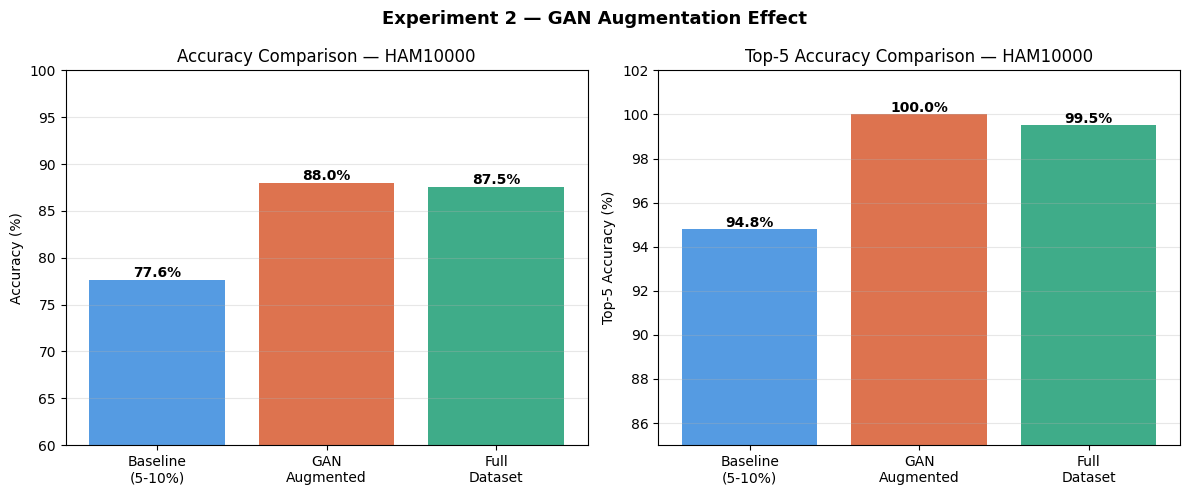

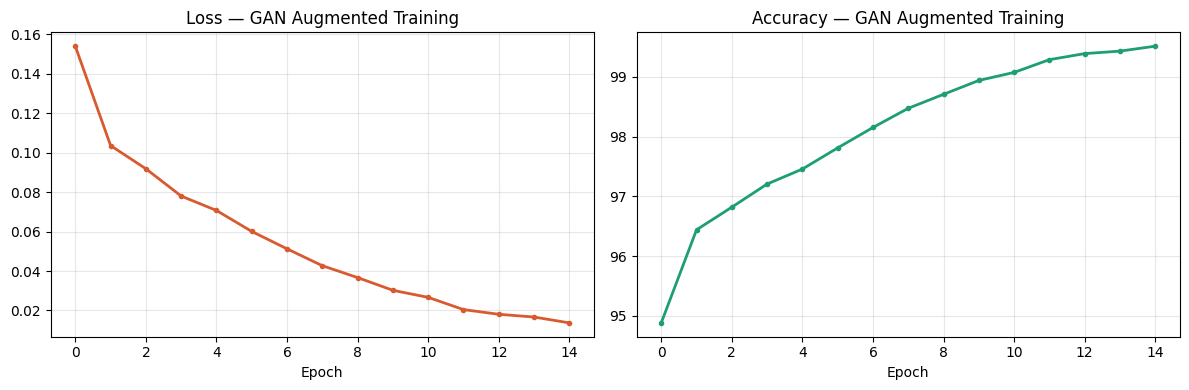


DAY 11 COMPLETE ✓
  Baseline Accuracy  : 77.59%
  GAN Aug Accuracy   : 87.97%
  Full Data Accuracy : 87.52%

  GAN Uplift:
    Accuracy gain : +10.38%
    Top-5 gain    : +5.20%

  Next → Day 12: GAN for ZebraMap ultra-rare classes


In [40]:
# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

experiments  = ['Baseline\n(5-10%)', 'GAN\nAugmented', 'Full\nDataset']
accuracies   = [77.59, aug_metrics['accuracy'], 87.52]
top5_accs    = [94.80, aug_metrics['top5_accuracy'], 99.50]
colors       = ['#378ADD', '#D85A30', '#1D9E75']

axes[0].bar(experiments, accuracies, color=colors, alpha=0.85)
axes[0].set_title('Accuracy Comparison — HAM10000')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(60, 100)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.3, f'{v:.1f}%',
                 ha='center', fontweight='bold', fontsize=10)

axes[1].bar(experiments, top5_accs, color=colors, alpha=0.85)
axes[1].set_title('Top-5 Accuracy Comparison — HAM10000')
axes[1].set_ylabel('Top-5 Accuracy (%)')
axes[1].set_ylim(85, 102)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(top5_accs):
    axes[1].text(i, v + 0.1, f'{v:.1f}%',
                 ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Experiment 2 — GAN Augmentation Effect',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results/day11_gan_uplift.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(aug_losses, color='#D85A30',
             linewidth=2, marker='o', markersize=3)
axes[0].set_title('Loss — GAN Augmented Training')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(aug_accs, color='#1D9E75',
             linewidth=2, marker='o', markersize=3)
axes[1].set_title('Accuracy — GAN Augmented Training')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results/day11_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save results
summary = {
    "day"             : 11,
    "experiment"      : "exp2_gan_augmented_ham",
    "train_size"      : len(train_ds),
    "test_size"       : len(test_ds),
    "real_train"      : len(real_train),
    "synthetic_train" : len(synt_df),
    "aug_metrics"     : aug_metrics,
    "baseline_metrics": baseline_metrics,
    "full_metrics"    : full_metrics,
    "uplift": {
        "accuracy_gain": round(
            aug_metrics['accuracy'] -
            baseline_metrics['accuracy'], 2),
        "top5_gain"    : round(
            aug_metrics['top5_accuracy'] -
            baseline_metrics['top5_accuracy'], 2)
    },
    "status": "Day 11 complete"
}

with open("/kaggle/working/results/day11_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 55)
print("DAY 11 COMPLETE ✓")
print("=" * 55)
print(f"  Baseline Accuracy  : {baseline_metrics['accuracy']}%")
print(f"  GAN Aug Accuracy   : {aug_metrics['accuracy']}%")
print(f"  Full Data Accuracy : {full_metrics['accuracy']}%")
print(f"\n  GAN Uplift:")
print(f"    Accuracy gain : {summary['uplift']['accuracy_gain']:+.2f}%")
print(f"    Top-5 gain    : {summary['uplift']['top5_gain']:+.2f}%")
print(f"\n  Next → Day 12: GAN for ZebraMap ultra-rare classes")